In [1]:
from pandas_plink import read_plink
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

import os
import csv
import json
import gc

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from phenotype_levels import phenotype_levels_used
from data_preparation import run_phenotype_pipeline, snp_matrix

2026-02-19 09:43:27.359892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 09:43:27.385395: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 09:43:27.393265: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-19 09:43:27.411639: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
fam_path = "/storage/plzen4-ntis/home/tadsova/rice_data/base_filtered_v0.7_0.8_10kb_1_0.8_50_1.fam"
pheno_path = "phenotypes/all_phenotypes.txt"
prefix = "/storage/plzen4-ntis/home/tadsova/rice_data/base_filtered_v0.7_0.8_10kb_1_0.8_50_1"

In [4]:
# výběr fenotypu
pheno = "PTH"

# masky
training_mask_probability = 0.9
test_mask_probability = 0.0

# Nastavení parametrů
START_MASK = 0.5
END_MASK = 0.95

results_file = "phenotype_benchmarks.csv"

In [5]:
X = snp_matrix(prefix)
#print(X)

/storage/plzen4-ntis/home/tadsova/.local-tensorflow24.12-r8.simg/lib/python3.12/site-packages/pandera/_pandas_deprecated.py:149: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


Celkem chybějících genotypů: 54071435
Genotype matrix shape: (3024, 404388)


In [6]:
def create_train_val_test_split(X, y, test_size=0.15, val_size=0.15, random_state=42):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    val_ratio = val_size / (1.0 - test_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_ratio,
        random_state=random_state,
        shuffle=True
    )
    
    print("Dokončené rozdělení dat")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
class GenomicDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=32, mask_prob=0.9, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.mask_prob = mask_prob
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.X) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        X_batch = self.X[batch_indices]
        y_batch = self.y[batch_indices]

        num_samples, num_snps = X_batch.shape
        X_out = np.zeros((num_samples, num_snps, 4), dtype=np.float32)
        
        mask = np.random.rand(num_samples, num_snps) < self.mask_prob

        for val in [0, 1, 2]:
            X_out[:, :, val] = (X_batch == val) & (~mask)
        
        X_out[:, :, 3] = mask
        
        return X_out.reshape(num_samples, -1), y_batch

In [8]:
class ProgressiveMaskingCallback(Callback):
    def __init__(self, generator, start_mask, end_mask, total_epochs):
        super().__init__()
        self.generator = generator
        self.start_mask = start_mask
        self.end_mask = end_mask
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_mask_prob = self.start_mask + (self.end_mask - self.start_mask) * (epoch / self.total_epochs)
        
        new_mask_prob = min(new_mask_prob, self.end_mask)
        
        self.generator.mask_prob = new_mask_prob

In [9]:
def build_genomic_model(input_dim, num_classes, learning_rate=1e-7):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # #layers.Dense(256, kernel_regularizer=regularizers.l2(0.01)),
        # layers.Dense(256),
        # layers.BatchNormalization(),
        # layers.Activation("relu"),

        # layers.Dense(128),
        # #layers.Dense(128, kernel_regularizer=regularizers.l2(0.01)),
        # layers.BatchNormalization(),
        # layers.Activation("relu"),
        
        layers.Dense(num_classes, activation='softmax')
    ])

    #loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy']
    )
    
    return model

In [10]:
def plot_history(history):
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Trénovací acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validační acc')
    plt.title('Přesnost trénování a validace')
    plt.xlabel('Epochs')
    plt.ylabel('Acc')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Trénovací loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validační loss')
    plt.title('Ztráta trénování a validace')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [11]:
def plot_confusion_matrix(model, generator, levels):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    y_true_list = []
    for i in range(len(generator)):
        _, y_batch = generator[i]
        y_true_list.append(np.argmax(y_batch, axis=1))
    
    y_true = np.concatenate(y_true_list)
    
    y_true = y_true[:len(y_pred)]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=levels, yticklabels=levels)
    
    plt.title('Matice záměn (z generátoru s maskou)')
    plt.ylabel('Skutečná hodnota')
    plt.xlabel('Predikovaná hodnota')
    plt.show()

In [12]:
# PRO JEDNOTLIVÉ TESTOVÁNÍ
X_ready, y_ready, current_levels, apriori_acc = run_phenotype_pipeline(pheno, X, pheno_path, fam_path)

# train/test data
X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(X_ready, y_ready)

y_integers = np.argmax(y_ready, axis=1)
class_weights_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)
class_weight_dict = dict(enumerate(class_weights_vals))

#train_gen = GenomicDataGenerator(X_train, y_train, mask_prob=training_mask_probability)
train_gen = GenomicDataGenerator(X_train, y_train, mask_prob=START_MASK)
val_gen   = GenomicDataGenerator(X_val, y_val, mask_prob=test_mask_probability, shuffle=False)
test_gen = GenomicDataGenerator(X_test, y_test, mask_prob=test_mask_probability, shuffle=False)

num_snps = X_train.shape[1]
classes_count = y_train.shape[1]


Počet vzorků 'PTH' po filtraci: 2261

Distribuce hodnot pro: PTH
VALUE
1    348
2    969
3    944
Name: count, dtype: int64
Celkem: 2261 vzorků
Apriori accuracy (majority class): 0.4286

One-hot kódování provedeno.
Tvar matice fenotypů: (2261, 3)
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 ...
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]

Původní počet vzorků v X: 3024
Počet vzorků po filtraci: 2261
Prvních 10 vybraných indexů řádků: [571 572 573 574 575 576 585 592 617 618]
Nová velikost matice X: (2261, 404388)
Dokončené rozdělení dat
X_train: (1582, 404388), y_train: (1582, 3)
X_val:   (339, 404388),   y_val:   (339, 3)
X_test:  (340, 404388),  y_test:  (340, 3)


In [13]:
model = build_genomic_model(num_snps * 4, classes_count)

prog_masking = ProgressiveMaskingCallback(
    generator=train_gen, 
    start_mask=START_MASK, 
    end_mask=END_MASK, 
    total_epochs=50
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-8,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop, reduce_lr, prog_masking],
    class_weight=class_weight_dict,
    verbose=1
)

2026-02-19 09:45:07.266811: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:198] Using CUDA malloc Async allocator for GPU: 0
2026-02-19 09:45:07.267174: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10308 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:03:00.0, compute capability: 6.1


Epoch 1/50


I0000 00:00:1771490709.585609   33408 service.cc:146] XLA service 0x14c7b4aa0900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771490709.585651   33408 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2026-02-19 09:45:09.599533: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-19 09:45:09.622304: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90600
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1771490709.732429   33408 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a reco

49/49 [==============================] - 37s 730ms/step - loss: 1.1561 - categorical_accuracy: 0.3495 - val_loss: 1.2372 - val_categorical_accuracy: 0.2188 - lr: 1.0000e-07
Epoch 2/50
49/49 [==============================] - 35s 717ms/step - loss: 1.1341 - categorical_accuracy: 0.3756 - val_loss: 1.2461 - val_categorical_accuracy: 0.2156 - lr: 1.0000e-07
Epoch 3/50
49/49 [==============================] - 35s 723ms/step - loss: 1.1451 - categorical_accuracy: 0.3718 - val_loss: 1.2415 - val_categorical_accuracy: 0.2406 - lr: 1.0000e-07
Epoch 4/50
49/49 [==============================] - 35s 715ms/step - loss: 1.1504 - categorical_accuracy: 0.3527 - val_loss: 1.2048 - val_categorical_accuracy: 0.2969 - lr: 1.0000e-07
Epoch 5/50
49/49 [==============================] - 35s 716ms/step - loss: 1.1148 - categorical_accuracy: 0.3693 - val_loss: 1.2329 - val_categorical_accuracy: 0.2937 - lr: 1.0000e-07
Epoch 6/50
49/49 [==============================] - 35s 712ms/step - loss: 1.1268 - categor

KeyboardInterrupt: 

In [ ]:
plot_history(history)

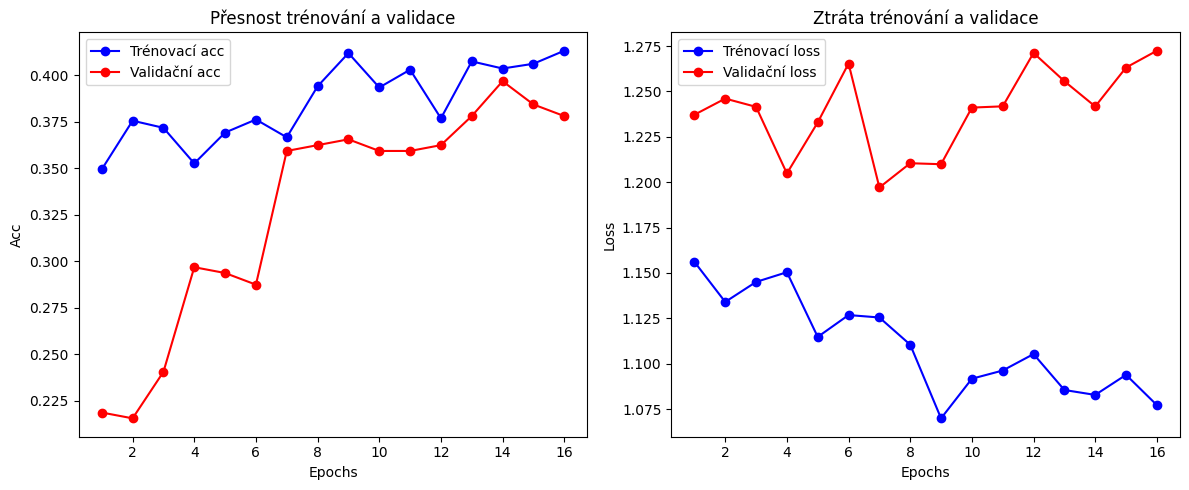

In [14]:
plot_history(model.history)

In [ ]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\nFinální přesnost na testovacích datech: {test_acc:.4f}")

In [ ]:
plot_confusion_matrix(model, test_gen, current_levels)

In [ ]:
y_pred_probs = model.predict(test_gen, verbose=0)

y_true_list = []
for i in range(len(test_gen)):
    _, y_batch = test_gen[i]
    y_true_list.append(y_batch)

y_true = np.concatenate(y_true_list)

avg_confidence = np.mean(np.max(y_pred_probs, axis=1))
actual_accuracy = np.mean(np.argmax(y_pred_probs, axis=1) == np.argmax(y_true, axis=1))

print(f"Průměrná jistota modelu: {avg_confidence:.2%}")
print(f"Reálná přesnost modelu: {actual_accuracy:.2%}")

diff = avg_confidence - actual_accuracy
print(f"Rozdíl (Overconfidence gap): {diff:.2%}")

In [ ]:
def log_final_results(phenotype, pheno_lvls, apriori_acc, test_acc, test_loss, total_samples, filename="phenotype_benchmarks.csv"):
    file_exists = os.path.isfile(filename)
    num_classes = len(pheno_lvls)
    lvls_str = "-".join(map(str, pheno_lvls))
    
    with open(filename, mode='a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow([
                "phenotype",
                "num_classes",
                "levels_map",
                "apriori_acc", 
                "model_acc", 
                "test_loss", 
                "total_samples"
            ])
        
        writer.writerow([
            phenotype,
            num_classes,
            lvls_str,
            f"{apriori_acc:.4f}", 
            f"{test_acc:.4f}", 
            f"{test_loss:.4f}", 
            total_samples
        ])
    
    print(f"Výsledky pro {phenotype} uloženy.")

In [ ]:
def plot_benchmark(filename):
    df = pd.read_csv(filename)
    df = df.sort_values('model_acc', ascending=False)
    plt.figure(figsize=(10, len(df) * 0.3))
    sns.barplot(x='model_acc', y='phenotype', data=df, color='#2ECC71', label='Model Accuracy')
    sns.barplot(x='apriori_acc', y='phenotype', data=df, color='#A9A9A9', label='Apriori Accuracy', alpha=0.8)

    for i, row in enumerate(df.itertuples()):
        plt.text(row.model_acc + 0.01, i, f'{row.model_acc:.2%}', va='center')

    plt.title('Apriori vs model accuracy')
    plt.xlabel('Accuracy')
    plt.xlim(0, 1.1)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
def plot_benchmark_scatter(filename):
    df = pd.read_csv(filename)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df, x='apriori_acc', y='model_acc', s=100)
    
    lims = [0, 1]
    plt.plot(lims, lims, '--r', alpha=0.75, label='hranice')

    plt.title('Apriori vs model accuracy')
    plt.xlabel('Apriory Accuracy')
    plt.ylabel('Model Test Accuracy')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

In [ ]:
def get_finished_phenotypes(filename):
    if not os.path.isfile(filename):
        return []
    df = pd.read_csv(filename)
    return df["phenotype"].tolist()

In [ ]:
def save_history_json(history, phenotype_name):
    history_dict = {}
    for key, values in history.history.items():
        history_dict[key] = [float(v) for v in values]

    with open(f"history_data/history_data_2/{phenotype_name}_history.json", "w") as f:
        json.dump(history_dict, f, indent=4)

In [ ]:

# finished_phenos = get_finished_phenotypes(results_file)

# for pheno_name in phenotype_levels_used.keys():
#     if pheno_name in finished_phenos:
#         continue
        
#     print("START")
    
#     X_ready, y_ready, levels, apriori_acc = run_phenotype_pipeline(pheno_name, X, pheno_path, fam_path)
    
#     total_n = len(y_ready)

#     X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(X_ready, y_ready)

#     y_integers = np.argmax(y_ready, axis=1)
#     class_weights_vals = compute_class_weight(
#         class_weight='balanced',
#         classes=np.unique(y_integers),
#         y=y_integers
#     )
#     class_weight_dict = dict(enumerate(class_weights_vals))

#     train_gen = GenomicDataGenerator(X_train, y_train, mask_prob=START_MASK)
#     val_gen   = GenomicDataGenerator(X_val, y_val, mask_prob=test_mask_probability, shuffle=False)
#     test_gen = GenomicDataGenerator(X_test, y_test, mask_prob=test_mask_probability, shuffle=False)
    
#     model = build_genomic_model(X_train.shape[1] * 4, y_train.shape[1])
    
#     prog_masking = ProgressiveMaskingCallback(
#         generator=train_gen, 
#         start_mask=START_MASK, 
#         end_mask=END_MASK, 
#         total_epochs=50
#     )
    
#     early_stop = EarlyStopping(
#         monitor='val_loss',
#         patience=10,
#         restore_best_weights=True
#     )
    
#     reduce_lr = ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=5,
#         min_lr=1e-8,
#         verbose=1
#     )
    
#     history = model.fit(
#         train_gen,
#         validation_data=val_gen,
#         epochs=50,
#         callbacks=[early_stop, reduce_lr, prog_masking],
#         class_weight=class_weight_dict,
#         verbose=1
#     )

#     save_history_json(history, pheno_name)

#     test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    
#     log_final_results(
#         phenotype=pheno_name,
#         pheno_lvls=levels,
#         apriori_acc=apriori_acc,
#         test_acc=test_acc,
#         test_loss=test_loss,
#         total_samples=total_n,
#         filename=results_file
#     )

#     del model
#     tf.keras.backend.clear_session()
#     gc.collect()
#     print("Paměť GPU vyčištěna")


In [ ]:
plot_benchmark(results_file)

In [ ]:
plot_benchmark_scatter(results_file)